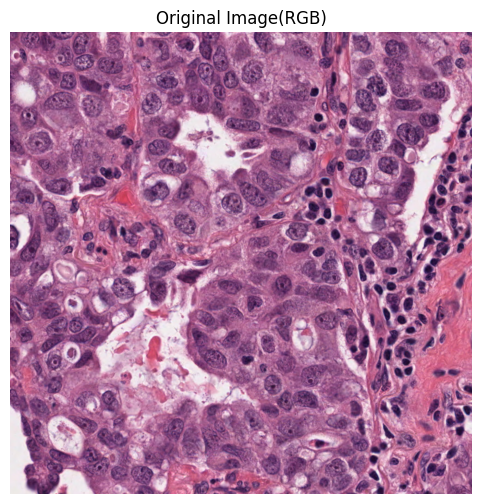

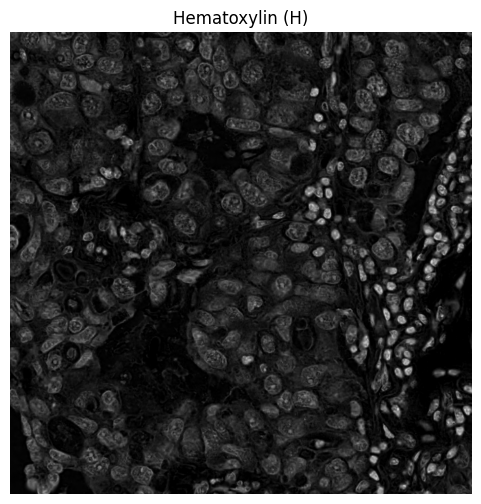

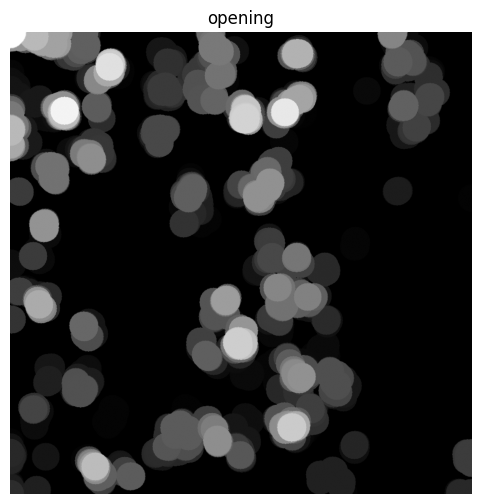

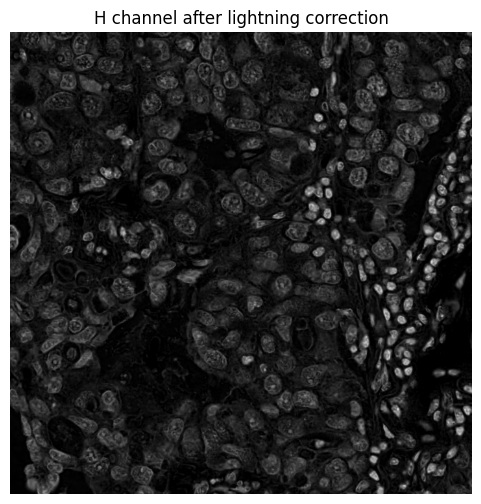

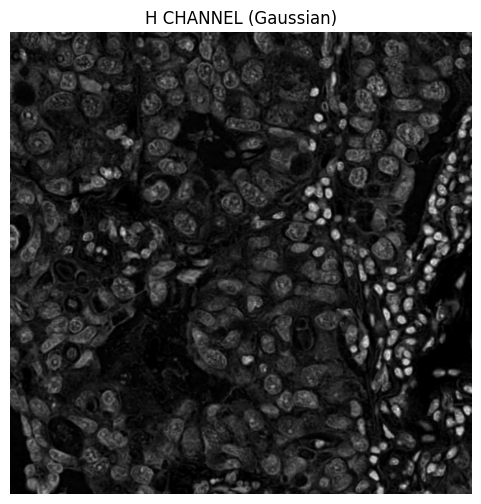

C:\Users\Yuri\AppData\Local\Temp\ipykernel_25912\2153630655.py:54: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_raw = morphology.remove_small_objects(mask_raw, min_size=120)
C:\Users\Yuri\AppData\Local\Temp\ipykernel_25912\2153630655.py:55: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_raw = morpho

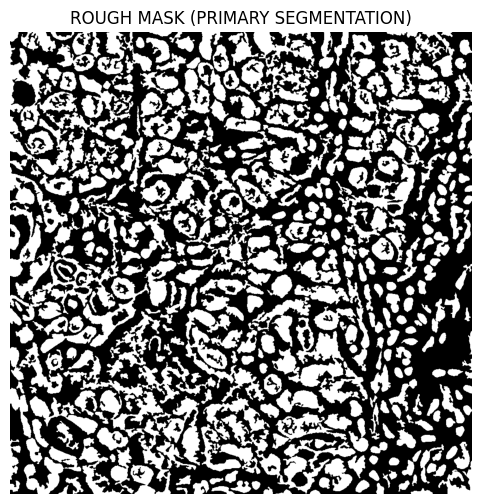

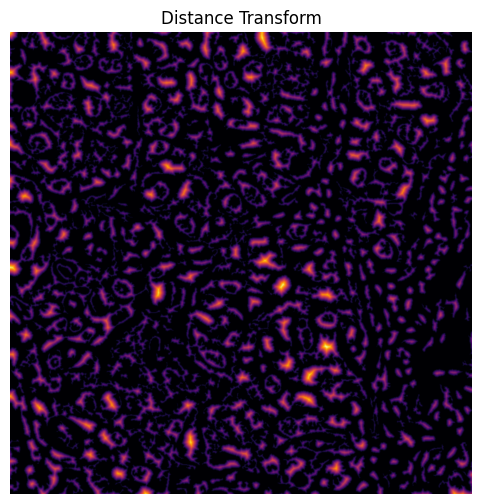

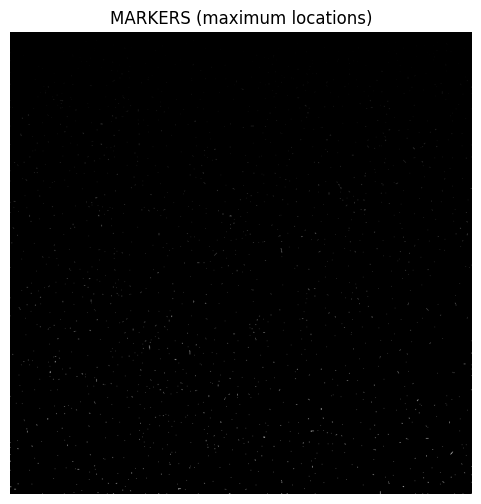

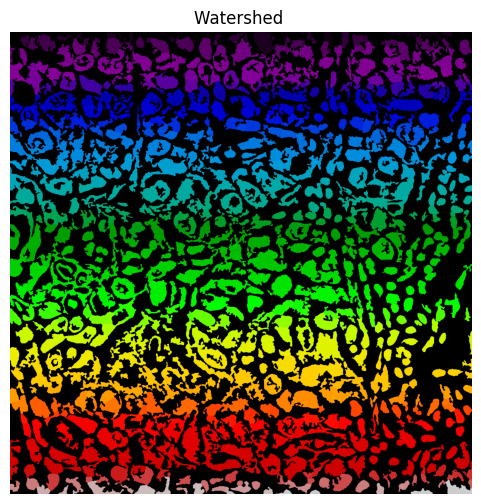

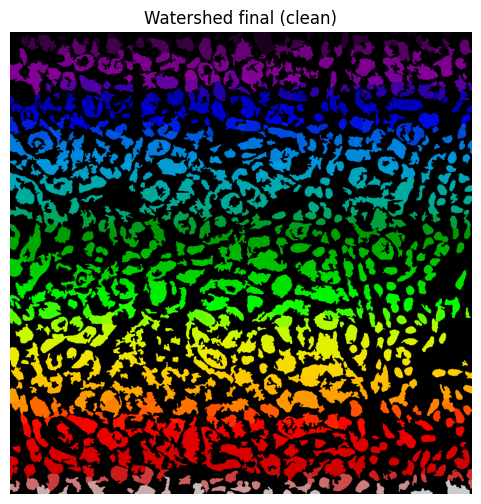

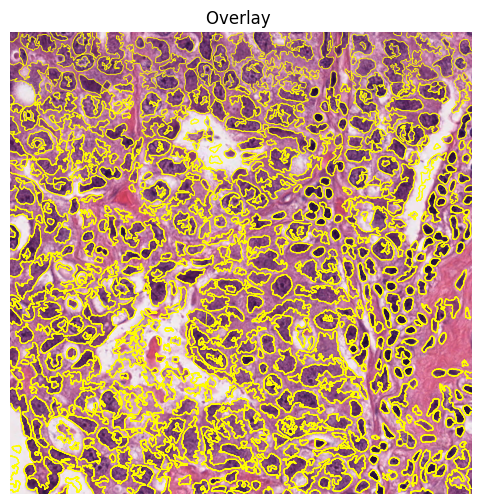

C:\Users\Yuri\AppData\Local\Temp\ipykernel_25912\2153630655.py:113: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  "mean_intensity_H": p.mean_intensity,


Number of nuclei detected: 1193


,area,circularity,mean_intensity_H,centroid_y,centroid_x
0,307.0,0.811000,0.154667,8.420195,7.433225
1,122.0,0.730900,0.232772,5.516393,95.409836
2,165.0,0.345927,0.173778,5.915152,165.369697
3,83.0,0.953656,0.088683,4.987952,182.385542
4,199.0,0.353460,0.143426,5.165829,231.889447


In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io,color,exposure,segmentation,morphology,filters,measure
from scipy import ndimage as ndi
import tifffile

plt.rcParams["figure.figsize"] = (6, 6)

# SHOW FUNCTION

def show(img, title, cmap="gray"):
    plt.figure()
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis("off")
    plt.show()


# IMG PATH
image_path = r"E:\opdownload\nuclei_cell_case\nuclei_cell_case\data\MoNuSeg\TCGA-38-6178-01Z-00-DX1.tif"


# 1.IMAGE READ
img_rgb = tifffile.imread(image_path)[..., :3]
show(img_rgb, "Original Image(RGB)", cmap=None)


# 2. HEMATOXYLIN CHANNEL (2.2)
hed = color.rgb2hed(img_rgb)
H = exposure.rescale_intensity(hed[..., 0], out_range=(0, 1))
show(H, "Hematoxylin (H)")


# 3. LIGHTNING CORRECTION
selem = morphology.disk(30)
background = morphology.opening(H, selem)
H_corr = exposure.rescale_intensity(H - background, out_range=(0, 1))

show(background, "opening")
show(H_corr, "H channel after lightning correction")


# 4. GAUSSIAN SMOOTHING
H_smooth = filters.gaussian(H_corr, sigma=1)
show(H_smooth, "H CHANNEL (Gaussian)")


# 5. PRIMARY SEGMENTATION
thresh = filters.threshold_sauvola(H_smooth, window_size=31, k=0.05)
mask_raw = H_smooth > thresh

mask_raw = morphology.remove_small_objects(mask_raw, min_size=120)
mask_raw = morphology.remove_small_holes(mask_raw, area_threshold=120)

show(mask_raw, "ROUGH MASK (PRIMARY SEGMENTATION)")


# 6. DISTANCE TRANSFORM 
distance = ndi.distance_transform_edt(mask_raw)
show(distance, "Distance Transform", cmap="inferno")


# 7. MARKERS (H-MAX)
maxima = morphology.h_maxima(distance, h=0.7)
markers = measure.label(maxima)

show(markers, "MARKERS (maximum locations)")


# 8. WATERSHED 
labels_ws = segmentation.watershed(
    -distance,
    markers,
    mask=mask_raw
)

show(labels_ws, "Watershed ", cmap="nipy_spectral")


# 9. PÓS-PROCESS

labels_final = np.zeros_like(labels_ws)
idx = 1

for p in measure.regionprops(labels_ws):
    if 80 < p.area < 3000 and p.eccentricity < 0.95:
        labels_final[labels_ws == p.label] = idx
        idx += 1

show(labels_final, "Watershed final (clean)", cmap="nipy_spectral")


# 10. FINAL OVERLAY
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.contour(labels_final, colors="yellow", linewidths=0.6)
plt.title("Overlay ")
plt.axis("off")
plt.show()


# 11. EXTRACTING MEASUREMENTS
features = []

for p in measure.regionprops(labels_final, intensity_image=H_smooth):
    circularity = 4 * np.pi * p.area / (p.perimeter**2 + 1e-6)

    features.append({
        "area": p.area,
        "circularity": circularity,
        "mean_intensity_H": p.mean_intensity,
        "centroid_y": p.centroid[0],
        "centroid_x": p.centroid[1]
    })

df_features = pd.DataFrame(features)
print("Number of nuclei detected:", len(df_features))
df_features.head()
